# Figure generator for the SAM2 progress deck

Run this top to bottom. It works **immediately in demo mode** (synthetic EM-like data) so you can
see the figure styling, then you flip `USE_DEMO = False` in the config cell and point it at your
real `output/` tree to get the real overlays.

It produces four slide-ready PNGs into a `figures/` folder:

1. `fig_correct_overlay.png`  -> slide 5 (a clean propagated mask on the EM)
2. `fig_failure_overlay.png`  -> slide 7 (a flagged frame, with any neighbour node that the mask has swallowed marked in red)
3. `fig_skeleton_overlay.png` -> slide 2 (an EM slice with the chain's skeleton nodes)
4. `fig_funnel.png` and `fig_riskcoverage.png` -> optional PNG versions of the slide 5 and slide 9 charts

Conventions it assumes (from the pipeline):
- masks at `output/<neuron>/chain_<idx:02d>/masks/mask_<catmaid_z:04d>.png`, saved in `_sam` space (full / SCALE)
- EM frames at `frames_root/frames_cache_s<SCALE>/z<file_z>.jpg`, also `_sam` space, so masks and frames line up
- `file_z = catmaid_z - FILE_Z_OFFSET`
- skeleton nodes have full-res tif coordinates, so `x_sam = x_tif / SCALE`
- `state.json` per chain gives the anchor z and the frame-to-z map

If a column name or path differs in your repo, the loaders print what they found so you can adjust the config.


## 0. Imports and shared style

In [1]:
# If anything is missing in your env:
# pip install numpy pandas pillow matplotlib scipy scikit-image
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    from scipy.ndimage import gaussian_filter, label as nd_label
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

# Deck palette (matches the slides)
NAVY      = "#1F4E79"
ACCENT    = "#2E75B6"
MUTED     = "#777777"
GREEN     = "#2E7D5B"
LEAK      = "#C0392B"      # neighbour node swallowed by the mask
OWN_NODE  = "#FFD400"      # the chain's own skeleton node
MASK_RGB  = (0.18, 0.46, 0.71)   # accent-blue mask fill

plt.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",   # any clean sans; the deck uses Arial
    "font.size": 12,
    "axes.edgecolor": "#CCCCCC",
})
Image.MAX_IMAGE_PIXELS = 500_000_000


## 1. Configure  (the only cell you edit for real data)

In [2]:
# -------- flip this to use your real pipeline outputs --------
USE_DEMO = True          # True = synthetic data, runs anywhere. False = read real files below.

# -------- paths (Windows raw strings are fine) --------
OUTPUT_ROOT = Path(r"E:\ZhenLab\Data\output_masks\run")     # holds <neuron>/chain_XX/...
FRAMES_ROOT = Path(r"E:\ZhenLab\Data\frames_root")          # holds frames_cache_s<SCALE>/
NODES_PATH  = Path(r"E:\ZhenLab\Data\annotate_df.parquet")  # export once: annotate_df.to_parquet(...)
TIF_DIR     = None        # optional: folder of full-res tif sections, used only if the frame cache misses

# -------- which chain to illustrate --------
NEURON     = "AVAL"
CHAIN_IDX  = 0

# -------- pipeline constants --------
SCALE         = 8         # the SAM2 downscale; mask and frame cache both live at full / SCALE
FILE_Z_OFFSET = 1         # file_z = catmaid_z - FILE_Z_OFFSET

# -------- how the nodes table is laid out (edit names to match your file) --------
# Needs an x and y in TIF pixels (converted to _sam by /SCALE here), a z (catmaid section), an id, and a cell label.
NODE_COLS = {"x": "x_tif", "y": "y_tif", "z": "z", "id": "node_id", "cell": "cell_name"}
# If your table already stores _sam pixel coords, set these and they win:
NODE_COLS_SAM = {"x": None, "y": None}   # e.g. {"x": "x_sam", "y": "y_sam"}

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
print("Writing figures to:", FIG_DIR.resolve())
print("Mode:", "DEMO (synthetic)" if USE_DEMO else "REAL (reading your files)")


Writing figures to: D:\Zhen Lab\SAM2 Segmentation\segmentation-playground\figures
Mode: DEMO (synthetic)


## 2. Demo data  (used only when USE_DEMO is True)

In [3]:
def _smooth_noise(n, sigma=6, seed=0):
    rng = np.random.default_rng(seed)
    a = rng.normal(0.5, 0.18, (n, n))
    if HAVE_SCIPY:
        a = gaussian_filter(a, sigma)
    a = (a - a.min()) / (np.ptp(a) + 1e-9)
    return a

def _ellipse(n, cx, cy, rx, ry, ang=0.0):
    yy, xx = np.mgrid[0:n, 0:n]
    xr =  (xx - cx) * np.cos(ang) + (yy - cy) * np.sin(ang)
    yr = -(xx - cx) * np.sin(ang) + (yy - cy) * np.cos(ang)
    return (xr / rx) ** 2 + (yr / ry) ** 2 <= 1.0

def make_demo():
    n = 700
    frame = (_smooth_noise(n) * 200 + 30).astype(np.uint8)

    good = _ellipse(n, 330, 350, 60, 165, ang=0.35)              # a clean neurite cross-section run
    leak_bulge = _ellipse(n, 455, 300, 75, 55)                   # a blob the mask spills into
    bad = good | leak_bulge

    # own skeleton nodes: a few points down the centreline of the good mask
    ys = np.linspace(210, 500, 5)
    xs = 330 + (ys - 350) * np.tan(0.35) * 0.0 + (ys - 350) * 0.18
    own = np.column_stack([xs, ys])

    # neighbour nodes: a cluster to the right; one of them lands inside the leak bulge
    neigh = np.array([[470, 300], [520, 320], [545, 285], [610, 340]], float)

    return {"frame": frame, "good": good, "bad": bad, "own": own, "neigh": neigh,
            "anchor_z": 1500, "bad_z": 1517}

DEMO = make_demo()
print("demo frame:", DEMO["frame"].shape, "| good-mask px:", int(DEMO["good"].sum()))


demo frame: (700, 700) | good-mask px: 31097


## 3. Loaders  (real-data path)

In [4]:
def _read_gray(path):
    return np.asarray(Image.open(path).convert("L"))

def load_state():
    if USE_DEMO:
        return {"anchor_catmaid_z": DEMO["anchor_z"], "frame_to_z": {}, "config": {"scale": SCALE}}
    p = OUTPUT_ROOT / NEURON / f"chain_{CHAIN_IDX:02d}" / "state.json"
    d = json.loads(Path(p).read_text())
    print("state.json: anchor z =", d.get("anchor_catmaid_z"), "| n_frames =", d.get("n_frames"))
    return d

def load_qc():
    if USE_DEMO:
        return None
    p = OUTPUT_ROOT / NEURON / f"chain_{CHAIN_IDX:02d}" / "qc.csv"
    if not Path(p).exists():
        print("no qc.csv at", p)
        return None
    df = pd.read_csv(p)
    print("qc.csv columns:", list(df.columns))
    return df

def load_frame(catmaid_z):
    if USE_DEMO:
        return DEMO["frame"]
    file_z = catmaid_z - FILE_Z_OFFSET
    cand = FRAMES_ROOT / f"frames_cache_s{SCALE}" / f"z{file_z}.jpg"
    if cand.exists():
        return _read_gray(cand)
    if TIF_DIR:
        hits = list(Path(TIF_DIR).glob(f"*z{file_z}*.tif")) + list(Path(TIF_DIR).glob(f"*z{file_z}*.tiff"))
        if hits:
            full = _read_gray(hits[0])
            return np.asarray(Image.fromarray(full).resize(
                (full.shape[1] // SCALE, full.shape[0] // SCALE), Image.BILINEAR))
    raise FileNotFoundError(f"no frame for catmaid_z={catmaid_z} (looked for {cand})")

def load_mask(catmaid_z):
    if USE_DEMO:
        return DEMO["bad"] if catmaid_z == DEMO["bad_z"] else DEMO["good"]
    p = OUTPUT_ROOT / NEURON / f"chain_{CHAIN_IDX:02d}" / "masks" / f"mask_{catmaid_z:04d}.png"
    return _read_gray(p) > 127

# nodes -> (own_xy, neighbour_xy) in _sam pixel coords at a given z
def _load_nodes_df():
    if USE_DEMO:
        return None
    df = pd.read_parquet(NODES_PATH) if NODES_PATH.suffix == ".parquet" else pd.read_csv(NODES_PATH)
    return df

_NODES = _load_nodes_df()

def nodes_at_z(catmaid_z, z_tol=0):
    if USE_DEMO:
        return DEMO["own"], DEMO["neigh"]
    df = _NODES
    zc = NODE_COLS["z"]
    sub = df[np.abs(df[zc] - catmaid_z) <= z_tol]
    if NODE_COLS_SAM["x"]:
        xs = sub[NODE_COLS_SAM["x"]].to_numpy(float)
        ys = sub[NODE_COLS_SAM["y"]].to_numpy(float)
    else:
        xs = sub[NODE_COLS["x"]].to_numpy(float) / SCALE
        ys = sub[NODE_COLS["y"]].to_numpy(float) / SCALE
    cell = sub[NODE_COLS["cell"]].astype(str).to_numpy()
    own = np.column_stack([xs[cell == NEURON], ys[cell == NEURON]])
    nei = np.column_stack([xs[cell != NEURON], ys[cell != NEURON]])
    return own, nei


## 4. Overlay renderer

In [5]:
def _crop_box(mask, pad, shape):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return 0, 0, shape[0], shape[1]
    y0 = max(0, ys.min() - pad); x0 = max(0, xs.min() - pad)
    y1 = min(shape[0], ys.max() + pad); x1 = min(shape[1], xs.max() + pad)
    return y0, x0, y1, x1

def make_overlay(frame, mask, own_pts=None, leak_pts=None, other_pts=None,
                 title=None, crop=True, pad=45, size=5.0):
    mask = mask.astype(bool)
    if crop:
        y0, x0, y1, x1 = _crop_box(mask, pad, frame.shape)
    else:
        y0, x0, y1, x1 = 0, 0, frame.shape[0], frame.shape[1]
    fc = frame[y0:y1, x0:x1]
    mc = mask[y0:y1, x0:x1]

    fig, ax = plt.subplots(figsize=(size, size))
    ax.imshow(fc, cmap="gray", interpolation="nearest")
    rgba = np.zeros((*mc.shape, 4))
    rgba[mc] = [*MASK_RGB, 0.42]
    ax.imshow(rgba, interpolation="nearest")
    ax.contour(mc.astype(float), levels=[0.5], colors=[ACCENT], linewidths=1.6)

    def scat(pts, color, s=70, edge="black", marker="o", z=5):
        if pts is None or len(pts) == 0:
            return
        pts = np.asarray(pts, float)
        ax.scatter(pts[:, 0] - x0, pts[:, 1] - y0, s=s, c=color,
                   edgecolors=edge, linewidths=0.7, marker=marker, zorder=z)

    scat(other_pts, "none", s=55, edge=MUTED)     # neighbour nodes outside the mask, hollow
    scat(own_pts, OWN_NODE, s=75)                  # the chain's own nodes
    scat(leak_pts, LEAK, s=95, marker="X", z=6)    # neighbour nodes the mask has swallowed

    ax.set_axis_off()
    if title:
        ax.set_title(title, color=NAVY, fontsize=13, fontweight="bold", pad=8)
    fig.tight_layout(pad=0.3)
    return fig

def save(fig, name, dpi=200):
    out = FIG_DIR / name
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("saved", out.resolve())


## 5. Figure: correct mask overlay  (slide 5)

Uses the anchor frame, which is the most reliable correct frame in a chain.

saved D:\Zhen Lab\SAM2 Segmentation\segmentation-playground\figures\fig_correct_overlay.png


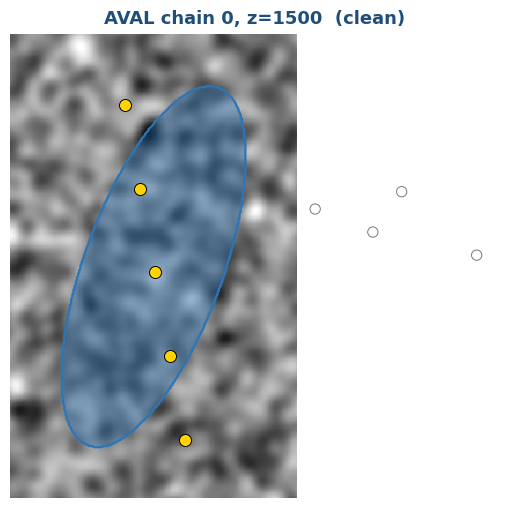

In [6]:
state = load_state()
anchor_z = int(state.get("anchor_catmaid_z"))

frame = load_frame(anchor_z)
mask = load_mask(anchor_z)
own, nei = nodes_at_z(anchor_z)

fig = make_overlay(frame, mask, own_pts=own, other_pts=nei,
                   title=f"{NEURON} chain {CHAIN_IDX}, z={anchor_z}  (clean)")
save(fig, "fig_correct_overlay.png")
plt.show()


## 6. Figure: failure overlay  (slide 7)

Auto-picks a flagged frame. If `qc.csv` has a flag-count column it uses that, otherwise it falls back to
the biggest frame-to-frame area jump in the chain. Any neighbour node that falls **inside** the mask is
marked with a red X. That is the leakage signal the deck proposes adding.

neighbour nodes swallowed by the mask: 2
saved D:\Zhen Lab\SAM2 Segmentation\segmentation-playground\figures\fig_failure_overlay.png


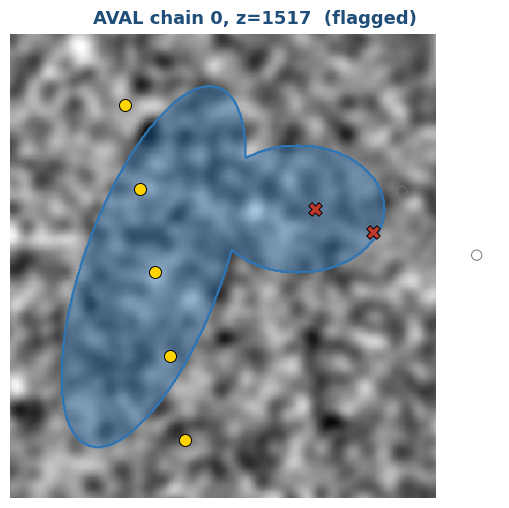

In [7]:
def pick_failure_z(qc):
    if USE_DEMO:
        return DEMO["bad_z"]
    # try qc.csv first
    if qc is not None:
        zcol = next((c for c in ["catmaid_z", "z", "frame_z"] if c in qc.columns), None)
        fcol = next((c for c in ["flag_count", "n_flags", "flags", "n_signals"] if c in qc.columns), None)
        if zcol and fcol:
            row = qc.sort_values(fcol, ascending=False).iloc[0]
            print(f"failure frame from qc: z={int(row[zcol])} ({fcol}={row[fcol]})")
            return int(row[zcol])
        if zcol and "area_ratio" in qc.columns:
            qc = qc.copy()
            qc["dev"] = (qc["area_ratio"] - 1.0).abs()
            row = qc.sort_values("dev", ascending=False).iloc[0]
            print(f"failure frame by area_ratio deviation: z={int(row[zcol])}")
            return int(row[zcol])
    # fallback: scan masks on disk for the biggest area jump
    mdir = OUTPUT_ROOT / NEURON / f"chain_{CHAIN_IDX:02d}" / "masks"
    zs = sorted(int(p.stem.split("_")[-1]) for p in mdir.glob("mask_*.png"))
    areas = np.array([load_mask(z).sum() for z in zs], float)
    jumps = np.abs(np.diff(areas)) / (areas[:-1] + 1)
    z = zs[int(np.argmax(jumps)) + 1]
    print(f"failure frame by area jump: z={z}")
    return z

bad_z = pick_failure_z(load_qc())
frame_b = load_frame(bad_z)
mask_b = load_mask(bad_z)
own_b, nei_b = nodes_at_z(bad_z)

# split neighbour nodes into inside-the-mask (leak) vs outside
def inside(pts, mask):
    keep = []
    H, W = mask.shape
    for x, y in np.asarray(pts, float):
        xi, yi = int(round(x)), int(round(y))
        if 0 <= yi < H and 0 <= xi < W and mask[yi, xi]:
            keep.append([x, y])
    return np.array(keep) if keep else np.empty((0, 2))

leak = inside(nei_b, mask_b)
outside = np.array([p for p in np.asarray(nei_b, float).tolist() if list(p) not in leak.tolist()]) if len(nei_b) else nei_b
print(f"neighbour nodes swallowed by the mask: {len(leak)}")

fig = make_overlay(frame_b, mask_b, own_pts=own_b, leak_pts=leak, other_pts=outside,
                   title=f"{NEURON} chain {CHAIN_IDX}, z={bad_z}  (flagged)")
save(fig, "fig_failure_overlay.png")
plt.show()


## 7. Figure: EM slice with skeleton  (slide 2, optional)

A wider view of the anchor frame with the chain's skeleton nodes, no mask. Good for the motivation slide.

saved D:\Zhen Lab\SAM2 Segmentation\segmentation-playground\figures\fig_skeleton_overlay.png


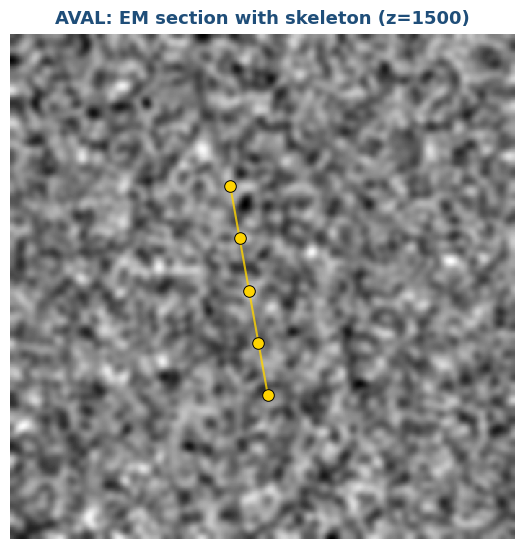

In [8]:
frame_a = load_frame(anchor_z)
own_a, nei_a = nodes_at_z(anchor_z)

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.imshow(frame_a, cmap="gray", interpolation="nearest")
if len(own_a):
    own_a = np.asarray(own_a, float)
    ax.plot(own_a[:, 0], own_a[:, 1], "-", color=OWN_NODE, lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(own_a[:, 0], own_a[:, 1], s=70, c=OWN_NODE, edgecolors="black", linewidths=0.7, zorder=5)
ax.set_axis_off()
ax.set_title(f"{NEURON}: EM section with skeleton (z={anchor_z})", color=NAVY, fontsize=13, fontweight="bold", pad=8)
fig.tight_layout(pad=0.3)
save(fig, "fig_skeleton_overlay.png")
plt.show()


## 8. Optional: PNG versions of the deck charts

The deck already has these as native PowerPoint charts. Generate PNGs only if you prefer images.

saved D:\Zhen Lab\SAM2 Segmentation\segmentation-playground\figures\fig_funnel.png


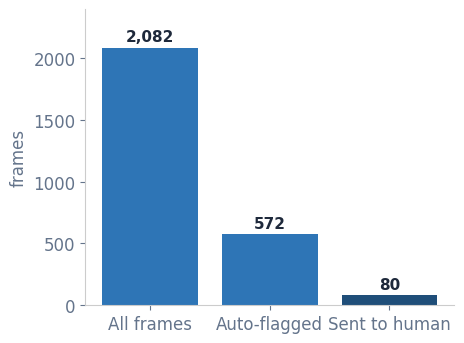

saved D:\Zhen Lab\SAM2 Segmentation\segmentation-playground\figures\fig_riskcoverage.png


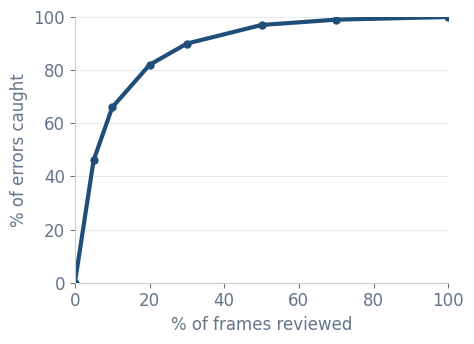

In [9]:
# Funnel (slide 5). Reads real counts from qc.csv if present, else uses the 5-neuron-run defaults.
counts = {"All frames": 2082, "Auto-flagged": 572, "Sent to human": 80}
fig, ax = plt.subplots(figsize=(4.8, 3.6))
bars = ax.bar(list(counts), list(counts.values()), color=[ACCENT, ACCENT, NAVY])
for b, v in zip(bars, counts.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 30, f"{v:,}", ha="center", va="bottom",
            fontweight="bold", color="#1E293B", fontsize=11)
ax.set_ylim(0, max(counts.values()) * 1.15)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.tick_params(colors="#64748B")
ax.set_ylabel("frames", color="#64748B")
fig.tight_layout()
save(fig, "fig_funnel.png")
plt.show()

# Risk-coverage curve (slide 9). Illustrative shape.
xs = [0, 5, 10, 20, 30, 50, 70, 100]
ys = [0, 46, 66, 82, 90, 97, 99, 100]
fig, ax = plt.subplots(figsize=(4.9, 3.6))
ax.plot(xs, ys, "-o", color=NAVY, lw=3, ms=5)
ax.set_xlabel("% of frames reviewed", color="#64748B")
ax.set_ylabel("% of errors caught", color="#64748B")
ax.set_ylim(0, 100); ax.set_xlim(0, 100)
ax.grid(axis="y", color="#E2E8F0", lw=0.6)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.tick_params(colors="#64748B")
fig.tight_layout()
save(fig, "fig_riskcoverage.png")
plt.show()


## Done

The PNGs are in `figures/`. To use them in the deck, open the .pptx, click the matching dashed
placeholder box, and Insert > Picture, or just drag the PNG on top of it.

To switch from demo to real data: set `USE_DEMO = False` in the config cell, fix the paths, and if a
loader complains, check the printed `qc.csv columns` / `state.json` line and adjust `NODE_COLS` or the
mask path to match your repo. Everything else stays the same.
